# 02 — Rule-Based Ranker V1

Pure hand-crafted signals. No ML. No embeddings.

**Scoring formula:**
```
final_score = title_score × component_score × engagement_multiplier

component_score = skill_depth(0.35) + career_text(0.30) + career_history(0.15) + yoe(0.12) + location(0.08)
```

**Title is a multiplicative gate** — a Tier-0 HR Manager with `title_score = 0.05` physically cannot break into top 100 no matter how many AI keywords they stuffed.

**Every candidate row carries ALL raw fields** — dates, companies, skills+duration, honeypot flags — so you can sanity-check any rank manually.

In [1]:
import json, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# Data was generated with today's actual date as reference.
# Using 2025-01-01 causes Δ = -17 months on every current-job end_date=None,
# flagging 99,995 candidates as honeypots (false positives).
CURRENT_DATE = datetime(2026, 6, 8)

DATA_PATH    = Path('../candidates.jsonl')
OUT_DIR      = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True)
OUT_CSV      = OUT_DIR / 'submission_v1_rulebased.csv'

print(f'CURRENT_DATE = {CURRENT_DATE.date()}')
print(f'Output → {OUT_CSV}')

CURRENT_DATE = 2026-06-08
Output → ..\outputs\submission_v1_rulebased.csv


In [2]:
# ── Title Tiers ───────────────────────────────────────────────────────────────
TIER5 = {
    'senior ai engineer','ml engineer','machine learning engineer','ai engineer',
    'applied ml engineer','nlp engineer','senior nlp engineer','search engineer',
    'recommendation systems engineer','ai research engineer',
    'staff machine learning engineer','lead ai engineer','ai specialist',
    'senior machine learning engineer','junior ml engineer'
}
TIER4 = {
    'data scientist','senior data scientist',
    'computer vision engineer','senior software engineer (ml)'
}
TIER3 = {
    'software engineer','senior software engineer',
    'backend engineer','full stack developer'
}
TIER2 = {
    'data engineer','analytics engineer','data analyst',
    'senior data engineer','cloud engineer','devops engineer'
}
TIER0 = {
    'hr manager','accountant','mechanical engineer','civil engineer',
    'content writer','marketing manager','sales executive','business analyst',
    'project manager','operations manager','customer support','graphic designer',
    'java developer','.net developer','mobile developer','frontend engineer','qa engineer'
}

TITLE_SCORE = {
    **{t: 1.00 for t in TIER5},
    **{t: 0.80 for t in TIER4},
    **{t: 0.40 for t in TIER3},
    **{t: 0.20 for t in TIER2},
    **{t: 0.05 for t in TIER0},
}

# ── Skill Tiers (calibrated from actual data — field is 'name', not 'skill_name') ──
# TIER_C: core retrieval/ranking infra that shows real depth
TIER_C = {
    'faiss','pinecone','weaviate','qdrant','milvus','pgvector',
    'opensearch','elasticsearch','bm25',
    'sentence transformers','hugging face transformers','llamaindex','haystack',
    'python','pytorch','tensorflow','scikit-learn',
    'lora','qlora','peft','weights & biases','wandb',
}
# TIER_B: applied AI/search patterns — relevant but easier to fake
TIER_B = {
    'langchain','embeddings','vector search','semantic search',
    'information retrieval','hybrid search',
    'recommendation systems','learning to rank',
    'rag','llms','fine-tuning','fine-tuning llms',
    'mlflow','mlops','bentoml','kubeflow','huggingface',
}
# TIER_A: cloud/infra — common, low differentiation
TIER_A = {'aws','gcp','azure','docker','kubernetes','terraform','airflow'}

ALL_JD  = TIER_C | TIER_B | TIER_A

# ── Career Text Keywords (retrieval/ranking domain signals) ───────────────────
CAREER_KW = [
    'vector','embedding','retrieval','semantic','rag','ranking','rerank',
    'faiss','bm25','fine-tun','llm','transformer','bert','inference',
    'recommendation','neural','language model','search','similarity',
    'index','ann','hnsw','dense retrieval','sparse','hybrid',
    'learning to rank','information retrieval','pgvector','llamaindex'
]

# ── Consulting firms ──────────────────────────────────────────────────────────
CONSULTING = {
    'tcs','infosys','wipro','accenture','cognizant','capgemini',
    'hcl','tech mahindra','mindtree','lti','hexaware','dxc'
}

AI_TITLE_KW = [
    'ml','ai','machine learning','data scientist','nlp',
    'neural','deep learning','computer vision','llm','language model'
]

print('Constants loaded.')
print(f'  Tier5={len(TIER5)}, Tier4={len(TIER4)}, Tier3={len(TIER3)}, Tier2={len(TIER2)}, Tier0={len(TIER0)}')
print(f'  SkillC={len(TIER_C)}, SkillB={len(TIER_B)}, SkillA={len(TIER_A)}')

Constants loaded.
  Tier5=15, Tier4=4, Tier3=4, Tier2=6, Tier0=17
  SkillC=22, SkillB=17, SkillA=7


In [3]:
print('Loading candidates...')
candidates = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in tqdm(f, desc='Reading'):
        line = line.strip()
        if line:
            candidates.append(json.loads(line))
print(f'Loaded {len(candidates):,} candidates')

Loading candidates...


Reading: 0it [00:00, ?it/s]

Loaded 100,000 candidates


## Section 2 — Enhanced Honeypot Detection

Three independent checks. Each returns structured detail (not just a flag) so you can see *why* a candidate was flagged when inspecting the top-20.

| Check | What it looks for | Key fields exposed |
|---|---|---|
| `date_mismatch` | `start→end` actual months ≠ `duration_months` by >2 | `hp_date_detail` shows each bad job |
| `yoe_mismatch` | Sum of all `duration_months` > `years_of_experience × 12 + 18` | `hp_yoe_career`, `hp_yoe_delta` |
| `skill_anomaly` | ≥4 skills listed as expert/advanced with `duration_months = 0` | `hp_expert_zero_skills` lists them |

In [4]:
def check_honeypot(c):
    """
    Returns a dict with full forensic detail, not just a bool.
    NOTE: skill field is 'name' (not 'skill_name') in this dataset.
    """
    profile = c.get('profile', {})
    career  = c.get('career_history', []) or []
    skills  = c.get('skills', []) or []
    reasons = []

    # ── Check 1: start/end date vs claimed duration_months ───────────────────
    date_mismatches = []
    for i, job in enumerate(career):
        s_str   = job.get('start_date')
        e_str   = job.get('end_date')
        claimed = job.get('duration_months', 0) or 0
        try:
            s = datetime.strptime(s_str, '%Y-%m-%d') if s_str else None
            e = datetime.strptime(e_str, '%Y-%m-%d') if e_str else CURRENT_DATE
            if s and e:
                actual = (e.year - s.year) * 12 + (e.month - s.month)
                if abs(actual - claimed) > 2:
                    date_mismatches.append({
                        'idx':     i,
                        'company': job.get('company', '?'),
                        'title':   job.get('title',   '?'),
                        'start':   s_str,
                        'end':     e_str,
                        'claimed': claimed,
                        'actual':  actual,
                        'delta':   actual - claimed,
                    })
        except (ValueError, TypeError):
            pass
    if date_mismatches:
        reasons.append('date_mismatch')

    # ── Check 2: total career months vs claimed YoE ───────────────────────────
    yoe_claimed  = float(profile.get('years_of_experience', 0) or 0)
    total_months = sum(j.get('duration_months', 0) or 0 for j in career)
    yoe_career   = round(total_months / 12, 1)

    date_months = 0
    for job in career:
        try:
            s = datetime.strptime(job['start_date'], '%Y-%m-%d') if job.get('start_date') else None
            e = datetime.strptime(job['end_date'],   '%Y-%m-%d') if job.get('end_date')   else CURRENT_DATE
            if s and e:
                date_months += max(0, (e.year - s.year) * 12 + (e.month - s.month))
        except (ValueError, TypeError):
            pass
    yoe_dates = round(date_months / 12, 1)

    if total_months > yoe_claimed * 12 + 18:
        reasons.append('yoe_mismatch')

    # ── Check 3: expert/advanced skill with 0 months (field = 'name') ────────
    expert_zero = []
    for s in skills:
        prof = (s.get('proficiency') or '').lower()
        dur  = s.get('duration_months', 0) or 0
        if prof in ('expert', 'advanced') and dur == 0:
            expert_zero.append(s.get('name', '?'))   # ← correct field
    if len(expert_zero) >= 4:
        reasons.append('skill_anomaly')

    return {
        'is_honeypot':     bool(reasons),
        'reasons':         reasons,
        'date_mismatches': date_mismatches,
        'yoe_claimed':     yoe_claimed,
        'yoe_career':      yoe_career,
        'yoe_dates':       yoe_dates,
        'yoe_delta':       round(yoe_career - yoe_claimed, 1),
        'expert_zero':     expert_zero,
        'n_expert_zero':   len(expert_zero),
    }

print('check_honeypot() defined.')

check_honeypot() defined.


In [5]:
# Quick stats on honeypots across full dataset
hp_results = [check_honeypot(c) for c in tqdm(candidates, desc='Honeypot scan')]
n_hp = sum(1 for r in hp_results if r['is_honeypot'])

from collections import Counter
reason_counter = Counter()
for r in hp_results:
    for reason in r['reasons']:
        reason_counter[reason] += 1

print(f'Total honeypots detected: {n_hp} / {len(candidates):,}')
print(f'  date_mismatch:  {reason_counter["date_mismatch"]}')
print(f'  yoe_mismatch:   {reason_counter["yoe_mismatch"]}')
print(f'  skill_anomaly:  {reason_counter["skill_anomaly"]}')

Honeypot scan:   0%|          | 0/100000 [00:00<?, ?it/s]

Total honeypots detected: 53 / 100,000
  date_mismatch:  35
  yoe_mismatch:   24
  skill_anomaly:  13


## Section 3 — Scoring Functions

Each function is isolated and returns a `0.0–1.0` value.

| Function | Weight | What it measures |
|---|---|---|
| `title_score` | multiplicative gate | Title tier (1.00→0.05) |
| `skill_depth_score` | 0.35 | Tier-C/B/A skills × duration weight |
| `career_text_score` | 0.30 | Retrieval/ranking keywords in job descriptions |
| `career_hist_score` | 0.15 | Product company, AI trajectory, seniority |
| `yoe_score` | 0.12 | Peak 5–8 yrs, sweet spot 3–12 |
| `location_score` | 0.08 | India Tier-1 city → 1.0, global hub → 0.6 |
| `engagement_mult` | ×0.50–1.00 | Recency, response rate, notice, open-to-work |

In [6]:
def get_title_score(title):
    t = (title or '').lower().strip()
    return TITLE_SCORE.get(t, 0.15)


def get_skill_depth_score(skills):
    """
    Skill field in data is 'name' (not 'skill_name').
    Also uses 'endorsements' as a quality signal alongside duration.

    Tier C = 3.0 pts  (vector DBs, training frameworks, retrieval infra)
    Tier B = 1.5 pts  (RAG, embeddings, LangChain, MLOps patterns)
    Tier A = 0.5 pts  (AWS, Docker, Kubernetes)

    Weight per skill = min(1.0, duration_weight + endorsement_bonus)
      duration_weight:    0 months → 0.10,  24+ months → 1.00
      endorsement_bonus:  0 endorsements → 0, 30+ endorsements → +0.30
    Normalised: 10 pts = full score (1.0).
    """
    score = 0.0
    for s in skills:
        name = (s.get('name') or '').lower().strip()   # ← correct field
        dur  = s.get('duration_months', 0) or 0
        end  = s.get('endorsements',   0) or 0

        dur_w  = min(1.0, dur / 24.0) if dur > 0 else 0.10
        end_w  = min(0.30, end / 30.0)                 # 30+ endorsements → +0.30
        weight = min(1.0, dur_w + end_w)

        if name in TIER_C:
            score += 3.0 * weight
        elif name in TIER_B:
            score += 1.5 * weight
        elif name in TIER_A:
            score += 0.5 * weight
    return min(1.0, score / 10.0)


def get_career_text_score(career):
    """
    Count how many retrieval/ranking JD keywords appear in job descriptions.
    5+ distinct keywords = full score (1.0).
    """
    if not career:
        return 0.0
    all_text = ' '.join(
        (j.get('description') or '') + ' ' + (j.get('title') or '')
        for j in career
    ).lower()
    hits = sum(1 for kw in CAREER_KW if kw in all_text)
    return min(1.0, hits / 5.0)


def get_career_hist_score(career):
    """Product company presence, AI/ML title trajectory, seniority signals."""
    if not career:
        return 0.0
    score     = 0.0
    companies = [(j.get('company') or '').lower() for j in career]
    titles    = [(j.get('title')   or '').lower() for j in career]

    is_consulting = any(any(ck in co for ck in CONSULTING) for co in companies)
    if not is_consulting:
        score += 0.30

    ai_count = sum(1 for t in titles if any(kw in t for kw in AI_TITLE_KW))
    score += min(0.35, ai_count * 0.12)

    if titles and any(kw in titles[-1] for kw in AI_TITLE_KW):
        score += 0.10

    has_senior = any(any(kw in t for kw in ['senior','lead','staff','principal','head','director'])
                     for t in titles)
    if has_senior:
        score += 0.10

    n_real_jobs = sum(1 for j in career if (j.get('duration_months') or 0) > 0)
    score += min(0.15, n_real_jobs * 0.05)

    return min(1.0, score)


def get_yoe_score(yoe):
    """Peak 5–8 yrs, sweet spot 3–12, penalise extremes."""
    if yoe is None: return 0.0
    yoe = float(yoe)
    if 5 <= yoe <= 8:         return 1.00
    elif 3 <= yoe < 5:        return 0.70 + (yoe - 3)  * 0.15
    elif 8 < yoe <= 12:       return 1.00 - (yoe - 8)  * 0.05
    elif 12 < yoe <= 18:      return 0.80 - (yoe - 12) * 0.04
    elif 1 <= yoe < 3:        return 0.20 + yoe * 0.15
    else:                     return 0.10


def get_location_score(country, location):
    """India Tier-1 city=1.0, India other=0.8, global hub=0.6, elsewhere=0.4"""
    country  = (country  or '').lower().strip()
    location = (location or '').lower().strip()
    if country == 'india':
        tier1 = ['bangalore','bengaluru','mumbai','hyderabad','pune',
                 'delhi','gurgaon','gurugram','noida','chennai']
        return 1.0 if any(c in location for c in tier1) else 0.8
    elif country in ['usa','united states','us','uk','united kingdom',
                     'canada','germany','singapore','netherlands','australia']:
        return 0.6
    else:
        return 0.4


def get_engagement_mult(eng):
    """Range 0.50–1.00. Applied last so it adjusts but never overrides talent."""
    if not eng: return 0.70
    score = 0.0
    active = float(eng.get('last_active_days', 999) or 999)
    if   active <= 7:    score += 0.30
    elif active <= 30:   score += 0.22
    elif active <= 90:   score += 0.14
    elif active <= 180:  score += 0.07
    else:                score += 0.02
    rr     = float(eng.get('response_rate', 0.5) or 0.5)
    score += rr * 0.25
    notice = float(eng.get('notice_period_days', 60) or 60)
    if   notice <= 15:  score += 0.25
    elif notice <= 30:  score += 0.20
    elif notice <= 60:  score += 0.12
    else:               score += 0.04
    if eng.get('open_to_work', False): score += 0.20
    return 0.50 + min(0.50, score * 0.50)


print('All scoring functions defined. Skill field = name, endorsements included.')

All scoring functions defined. Skill field = name, endorsements included.


## Section 4 — Score Every Candidate

`score_candidate()` returns a **flat dict with 45+ fields** — every raw signal, every partial score, every honeypot flag.
This means the resulting DataFrame is your inspection tool: sort by any column, filter on any flag, no black boxes.

In [7]:
def score_candidate(c):
    """
    Returns a flat dict with ALL signals — raw fields, sub-scores, honeypot forensics.
    Skill field is 'name'. Endorsements included in skill scoring.
    """
    cid     = c.get('candidate_id', '')
    profile = c.get('profile', {})
    career  = c.get('career_history', []) or []
    skills  = c.get('skills', []) or []
    eng     = c.get('engagement') or {}

    title    = profile.get('current_title', '') or ''
    yoe      = profile.get('years_of_experience', 0) or 0
    country  = profile.get('country',  '') or ''
    location = profile.get('location', '') or ''
    name     = profile.get('anonymized_name', '') or ''

    # ── Honeypot ──────────────────────────────────────────────────────────────
    hp = check_honeypot(c)

    # ── Keyword stuffer check ─────────────────────────────────────────────────
    title_lower = title.lower().strip()
    is_tier0    = title_lower in TIER0
    # correct field = 'name'
    skill_names = {(s.get('name') or '').lower().strip() for s in skills}
    n_jd_skills = len(skill_names & ALL_JD)
    is_stuffer  = is_tier0 and n_jd_skills >= 4

    # ── Skill breakdown ───────────────────────────────────────────────────────
    tier_c_present = sorted(skill_names & TIER_C)
    tier_b_present = sorted(skill_names & TIER_B)
    tier_a_present = sorted(skill_names & TIER_A)

    # ── Career breakdown ──────────────────────────────────────────────────────
    companies     = [j.get('company', '') or '' for j in career]
    career_titles = [j.get('title',   '') or '' for j in career]

    earliest_start = None
    for job in career:
        try:
            d = datetime.strptime(job['start_date'], '%Y-%m-%d')
            if earliest_start is None or d < earliest_start:
                earliest_start = d
        except (ValueError, TypeError, KeyError):
            pass
    career_span_yrs = round((CURRENT_DATE - earliest_start).days / 365, 1) if earliest_start else None

    is_consulting   = any(any(ck in co.lower() for ck in CONSULTING) for co in companies if co)
    has_senior_flag = any(any(kw in t.lower() for kw in ['senior','lead','staff','principal','head','director'])
                         for t in career_titles)

    all_text = ' '.join(
        (j.get('description') or '') + ' ' + (j.get('title') or '')
        for j in career
    ).lower()
    career_kw_hits = [kw for kw in CAREER_KW if kw in all_text]

    # ── Sub-scores ────────────────────────────────────────────────────────────
    t_score  = get_title_score(title)
    s_score  = get_skill_depth_score(skills)
    ct_score = get_career_text_score(career)
    ch_score = get_career_hist_score(career)
    y_score  = get_yoe_score(yoe)
    l_score  = get_location_score(country, location)
    e_mult   = get_engagement_mult(eng)

    component = (
        s_score  * 0.35 +
        ct_score * 0.30 +
        ch_score * 0.15 +
        y_score  * 0.12 +
        l_score  * 0.08
    )

    final = 0.0 if hp['is_honeypot'] else t_score * component * e_mult

    return {
        # Identity
        'candidate_id':    cid,
        'name':            name,
        'title':           title,
        'country':         country,
        'location':        location,
        'yoe_claimed':     yoe,

        # Honeypot forensics (all fields exposed)
        'is_honeypot':          hp['is_honeypot'],
        'hp_reasons':           '|'.join(hp['reasons']),
        'hp_n_date_mismatches': len(hp['date_mismatches']),
        'hp_date_detail':       str([f"{d['company']} claimed={d['claimed']} actual={d['actual']} Δ={d['delta']}"
                                     for d in hp['date_mismatches'][:3]]),
        'hp_yoe_claimed':       hp['yoe_claimed'],
        'hp_yoe_career':        hp['yoe_career'],
        'hp_yoe_dates':         hp['yoe_dates'],
        'hp_yoe_delta':         hp['yoe_delta'],
        'hp_n_expert_zero':     hp['n_expert_zero'],
        'hp_expert_zero':       '|'.join(hp['expert_zero'][:6]),

        # Keyword stuffer signals
        'is_stuffer':  is_stuffer,
        'is_tier0':    is_tier0,
        'n_jd_skills': n_jd_skills,

        # Skills (full breakdown)
        'n_skills':    len(skills),
        'n_tier_c':    len(tier_c_present),
        'n_tier_b':    len(tier_b_present),
        'n_tier_a':    len(tier_a_present),
        'tier_c_list': '|'.join(tier_c_present),
        'tier_b_list': '|'.join(tier_b_present),
        'tier_a_list': '|'.join(tier_a_present),

        # Career (full breakdown)
        'n_jobs':           len(career),
        'companies':        ' → '.join(companies[:5]),
        'career_titles':    ' → '.join(career_titles[:5]),
        'earliest_start':   str(earliest_start.date()) if earliest_start else '',
        'career_span_yrs':  career_span_yrs,
        'is_consulting':    is_consulting,
        'has_senior_title': has_senior_flag,
        'n_career_kw':      len(career_kw_hits),
        'career_kw_list':   '|'.join(career_kw_hits[:10]),

        # Behavioral signals
        'last_active_days':   eng.get('last_active_days'),
        'response_rate':      eng.get('response_rate'),
        'notice_period_days': eng.get('notice_period_days'),
        'open_to_work':       eng.get('open_to_work'),
        'has_github':         bool(eng.get('github_url', '')),

        # Sub-scores (fully transparent)
        'score_title':   round(t_score,  4),
        'score_skill':   round(s_score,  4),
        'score_cartext': round(ct_score, 4),
        'score_carhist': round(ch_score, 4),
        'score_yoe':     round(y_score,  4),
        'score_loc':     round(l_score,  4),
        'score_eng':     round(e_mult,   4),
        'score_final':   round(final,    6),
    }

print('score_candidate() defined.')

score_candidate() defined.


In [8]:
print('Scoring all candidates...')
rows = [score_candidate(c) for c in tqdm(candidates, desc='Scoring')]
df = pd.DataFrame(rows)
df.sort_values('score_final', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
df.index += 1   # rank starts at 1

print(f'DataFrame shape: {df.shape}')
print(f'\nHoneypots excluded:  {df["is_honeypot"].sum():,}')
print(f'Keyword stuffers:    {df["is_stuffer"].sum():,}')
print(f'Non-zero scores:     {(df["score_final"] > 0).sum():,}')
print(f'\nTop score: {df["score_final"].iloc[0]:.4f}')
print(f'Score at rank 100: {df["score_final"].iloc[99]:.4f}')

Scoring all candidates...


Scoring:   0%|          | 0/100000 [00:00<?, ?it/s]

DataFrame shape: (100000, 48)

Honeypots excluded:  53
Keyword stuffers:    8,101
Non-zero scores:     99,947

Top score: 0.7000
Score at rank 100: 0.6661


## Section 5 — Inspect Results

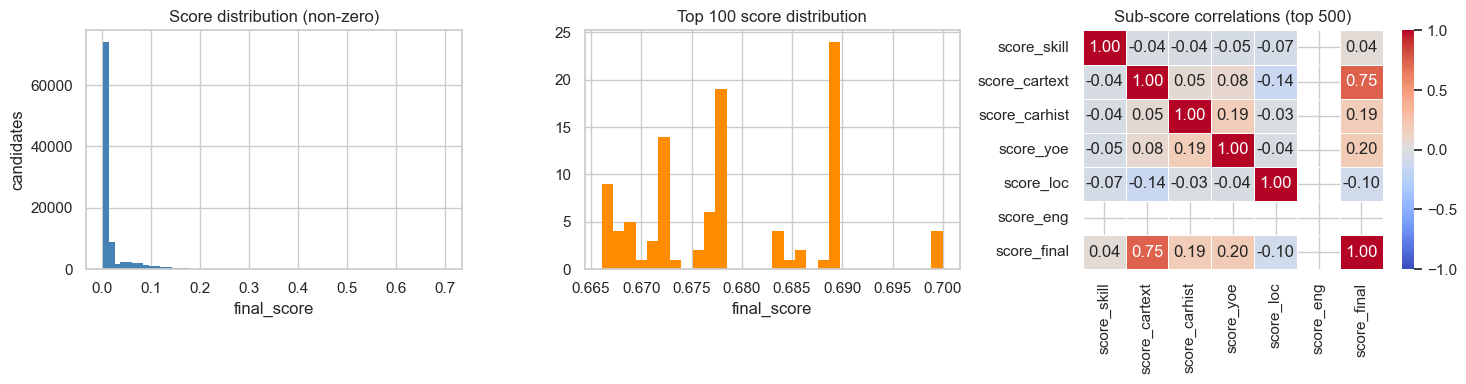

Score distribution chart saved.


In [9]:
# ── Score distribution across all candidates ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

nonzero = df[df['score_final'] > 0]['score_final']
top100  = df.head(100)['score_final']

axes[0].hist(nonzero, bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('Score distribution (non-zero)')
axes[0].set_xlabel('final_score')
axes[0].set_ylabel('candidates')

axes[1].hist(top100, bins=30, color='darkorange', edgecolor='none')
axes[1].set_title('Top 100 score distribution')
axes[1].set_xlabel('final_score')

# Sub-score correlation heatmap (top 500)
score_cols = ['score_skill','score_cartext','score_carhist','score_yoe','score_loc','score_eng','score_final']
corr = df.head(500)[score_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], vmin=-1, vmax=1, linewidths=0.5)
axes[2].set_title('Sub-score correlations (top 500)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'v1_score_distribution.png', dpi=120)
plt.show()
print('Score distribution chart saved.')

In [10]:
# ── Top 20 — FULL DETAIL VIEW ─────────────────────────────────────────────────
# Every signal is visible so you can verify each rank manually.

INSPECT_COLS = [
    'candidate_id','name','title','country','location','yoe_claimed',
    # Honeypot signals
    'is_honeypot','hp_reasons','hp_yoe_delta','hp_n_expert_zero','hp_expert_zero',
    # Stuffer signals
    'is_stuffer','is_tier0','n_jd_skills',
    # Skills
    'n_tier_c','n_tier_b','n_tier_a','tier_c_list','tier_b_list',
    # Career
    'n_jobs','companies','career_titles','career_span_yrs','is_consulting',
    'has_senior_title','n_career_kw','career_kw_list',
    # Behavioral
    'last_active_days','response_rate','notice_period_days','open_to_work','has_github',
    # Scores
    'score_title','score_skill','score_cartext','score_carhist',
    'score_yoe','score_loc','score_eng','score_final',
]

top20 = df.head(20)[INSPECT_COLS].copy()
print('=== TOP 20 — FULL DETAIL ===')
display(top20)

=== TOP 20 — FULL DETAIL ===


,candidate_id,name,title,country,location,yoe_claimed,is_honeypot,hp_reasons,hp_yoe_delta,hp_n_expert_zero,hp_expert_zero,is_stuffer,is_tier0,n_jd_skills,n_tier_c,n_tier_b,n_tier_a,tier_c_list,tier_b_list,n_jobs,companies,career_titles,career_span_yrs,is_consulting,has_senior_title,n_career_kw,career_kw_list,last_active_days,response_rate,notice_period_days,open_to_work,has_github,score_title,score_skill,score_cartext,score_carhist,score_yoe,score_loc,score_eng,score_final
1,CAND_0040178,Anika Bhatia,ML Engineer,India,"Pune, Maharashtra",5.0000,False,,-0.1000,0,,False,False,9,4,5,0,opensearch|python|weaviate|weights & biases,fine-tuning llms|kubeflow|learning to rank|mlflow|vector search,3,Meesho → InMobi → Niramai,ML Engineer → Senior Software Engineer (ML) → ML Engineer,4.9000,False,True,5,ranking|fine-tun|transformer|bert|recommendation,None,None,None,None,False,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7000,0.7000
2,CAND_0053527,Krishna Iyer,Junior ML Engineer,India,"Bangalore, Karnataka",7.0000,False,,-0.2000,0,,False,False,5,4,1,0,pinecone|qdrant|qlora|scikit-learn,mlops,3,PhonePe → PolicyBazaar → Verloop.io,Junior ML Engineer → Senior Software Engineer (ML) → AI Specialist,6.8000,False,True,5,ranking|fine-tun|transformer|bert|recommendation,None,None,None,None,False,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7000,0.7000
3,CAND_0092278,Ananya Arora,Senior NLP Engineer,India,"Pune, Maharashtra",6.8000,False,,-0.1000,0,,False,False,11,7,4,0,elasticsearch|hugging face transformers|milvus|peft|pgvector|qlora|tensorflow,llms|mlflow|semantic search|vector search,3,Microsoft → Paytm → Saarthi.ai,Senior NLP Engineer → Senior NLP Engineer → Senior NLP Engineer,6.6000,False,True,13,embedding|retrieval|rag|ranking|rerank|faiss|bm25|llm|transformer|recommendation,None,None,None,None,False,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7000,0.7000
4,CAND_0018499,Aarav Trivedi,Senior Machine Learning Engineer,India,"Noida, Uttar Pradesh",7.2000,False,,0.0000,0,,False,False,13,7,6,0,bm25|milvus|pinecone|qlora|scikit-learn|weaviate|weights & biases,embeddings|information retrieval|langchain|learning to rank|rag|recommendation systems,3,Zomato → Google → Flipkart,Senior Machine Learning Engineer → Staff Machine Learning Engineer → Senior Machine Le...,7.1000,False,True,13,embedding|retrieval|rag|ranking|rerank|faiss|bm25|fine-tun|llm|inference,None,None,None,None,False,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7000,0.7000
5,CAND_0087630,Aisha Rao,AI Engineer,India,"Gurgaon, Haryana",7.2000,False,,-0.1000,0,,False,False,10,8,2,0,bm25|elasticsearch|hugging face transformers|opensearch|pgvector|qlora|sentence transf...,embeddings|learning to rank,3,Vedantu → Haptik → Glance,AI Engineer → Applied ML Engineer → Applied ML Engineer,7.3000,False,False,5,embedding|ranking|transformer|recommendation|similarity,None,None,None,None,False,1.0000,1.0000,1.0000,0.9000,1.0000,1.0000,0.7000,0.6895
6,CAND_0067643,Suresh Patel,AI Research Engineer,India,"Chennai, Tamil Nadu",6.0000,False,,-0.1000,0,,False,False,6,4,2,0,bm25|elasticsearch|lora|qdrant,fine-tuning llms|learning to rank,3,PhonePe → PolicyBazaar → Saarthi.ai,AI Research Engineer → AI Specialist → Data Scientist,5.9000,False,False,6,ranking|fine-tun|llm|inference|recommendation|search,None,None,None,None,False,1.0000,1.0000,1.0000,0.9000,1.0000,1.0000,0.7000,0.6895
7,CAND_0011327,Pranav Krishnan,AI Research Engineer,India,"Gurgaon, Haryana",6.3000,False,,-0.1000,0,,False,False,7,4,2,1,haystack|opensearch|sentence transformers|weights & biases,mlflow|semantic search,3,Krutrim → Razorpay → Meesho,AI Research Engineer → AI Specialist → Junior ML Engineer,6.2000,False,False,6,ranking|fine-tun|transformer|bert|recommendation|search,None,None,None,None,False,1.0000,1.0000,1.0000,0.9000,1.0000,1.0000,0.7000,0.6895
8,CAND_0039383,Riya Malhotra,Applied ML Engineer,India,"Gurgaon, Haryana",7.1000,False,,-0.1000,0,,False,False,10,6,4,0,elasticsearch|faiss|hugging face transformers|lora|pgvector|qlora,ku

In [11]:
# ── Where do honeypots land in the ranking? ───────────────────────────────────
hp_df = df[df['is_honeypot']].head(20)[['candidate_id','name','title','hp_reasons',
    'hp_yoe_delta','hp_n_expert_zero','hp_expert_zero','hp_date_detail','score_final']]

print(f'Honeypots in top 100: {df.head(100)["is_honeypot"].sum()}  ← must be 0')
print(f'Total honeypots: {df["is_honeypot"].sum()}')
print('\nSample honeypots (their scores = 0.0):')
display(hp_df)

Honeypots in top 100: 0  ← must be 0
Total honeypots: 53

Sample honeypots (their scores = 0.0):


,candidate_id,name,title,hp_reasons,hp_yoe_delta,hp_n_expert_zero,hp_expert_zero,hp_date_detail,score_final
99948,CAND_0096150,Vikram Pandey,Accountant,date_mismatch,-13.9000,0,,['Wipro claimed=10 actual=25 Δ=15'],0.0000
99949,CAND_0086808,Ishaan Dutta,Graphic Designer,date_mismatch,-10.2000,0,,['TCS claimed=15 actual=19 Δ=4'],0.0000
99950,CAND_0036299,Rajesh Sharma,Mobile Developer,date_mismatch,-11.5000,0,,['Cognizant claimed=8 actual=44 Δ=36'],0.0000
99951,CAND_0065096,Neha Ghosh,Civil Engineer,skill_anomaly,0.0000,4,ETL|Tally|Flask|Rust,[],0.0000
99952,CAND_0037539,Aryan Subramanian,Project Manager,date_mismatch|yoe_mismatch,4.7000,0,,['Stark Industries claimed=106 actual=49 Δ=-57'],0.0000
99953,CAND_0074119,Saanvi Malhotra,Content Writer,date_mismatch,-10.3000,0,,['Globex Inc claimed=13 actual=25 Δ=12'],0.0000
99954,CAND_0046689,Nisha Banerjee,Business Analyst,skill_anomaly,-0.1000,4,Node.js|SQL|gRPC|Spark,[],0.0000
99955,CAND_0073853,Arnav Pillai,Operations Manager,skill_anomaly,-0.2000,5,CI/CD|Marketing|GCP|Excel|AWS,[],0.0000
99956,CAND_0065710,Dhruv Gupta,Marketing Manager,date_mismatch|yoe_mismatch,5.1000,0,,['Hooli claimed=100 actual=38 Δ=-62'],0.0000
99957,CAND_0095480,Aisha Sharma,.NET Developer,skill_anomaly,-0.1000,4,Agile|React|Snowflake|Content Writing,[],0.0000


In [12]:
# ── Where do keyword stuffers land? ──────────────────────────────────────────
# Should NOT appear in top 100. The title gate (0.05) keeps them out.
stuffers_in_top100 = df.head(100)[df.head(100)['is_stuffer']]
print(f'Keyword stuffers in top 100: {len(stuffers_in_top100)}  ← must be 0')

# Show where the top-ranked stuffer ended up
top_stuffer_rank = df[df['is_stuffer']].index.min()
print(f'Best-ranked stuffer is at rank: {top_stuffer_rank}')

# Sample stuffers and their scores
sample_stuffers = df[df['is_stuffer']].head(5)[
    ['candidate_id','name','title','n_jd_skills','tier_c_list',
     'score_title','score_skill','score_final']
]
print('\nSample stuffers (title_score=0.05 kills them):')
display(sample_stuffers)

Keyword stuffers in top 100: 0  ← must be 0
Best-ranked stuffer is at rank: 17127

Sample stuffers (title_score=0.05 kills them):


,candidate_id,name,title,n_jd_skills,tier_c_list,score_title,score_skill,score_final
17127,CAND_0062729,Ritu Iyer,Content Writer,12,pinecone|sentence transformers,0.0500,1.0000,0.0258
17128,CAND_0004570,Meera Krishnan,Marketing Manager,12,faiss|hugging face transformers|pinecone|sentence transformers,0.0500,1.0000,0.0258
17129,CAND_0061649,Karan Sen,Business Analyst,12,faiss|hugging face transformers|pinecone|sentence transformers,0.0500,1.0000,0.0258
17130,CAND_0075291,Myra Naidu,HR Manager,10,faiss|hugging face transformers|sentence transformers,0.0500,1.0000,0.0258
17131,CAND_0084630,Pranav Shah,Business Analyst,11,faiss|hugging face transformers|pinecone|sentence transformers,0.0500,1.0000,0.0258


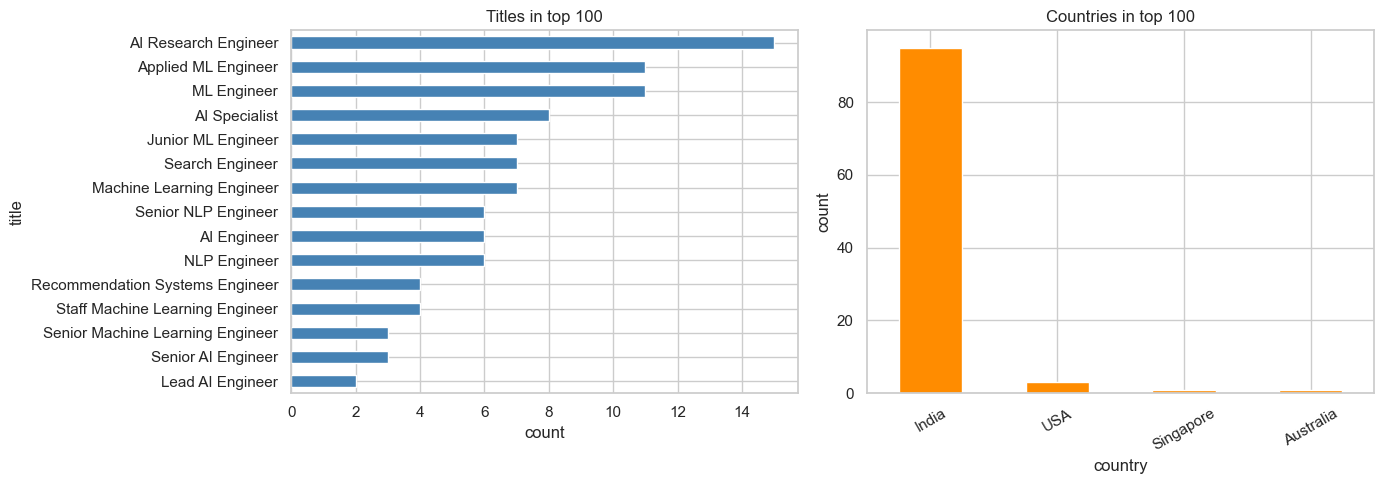

In [13]:
# ── Title distribution in top 100 ────────────────────────────────────────────
title_counts = df.head(100)['title'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

title_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Titles in top 100')
axes[0].set_xlabel('count')
axes[0].invert_yaxis()

# Country distribution in top 100
country_counts = df.head(100)['country'].value_counts().head(10)
country_counts.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Countries in top 100')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / 'v1_top100_breakdown.png', dpi=120)
plt.show()

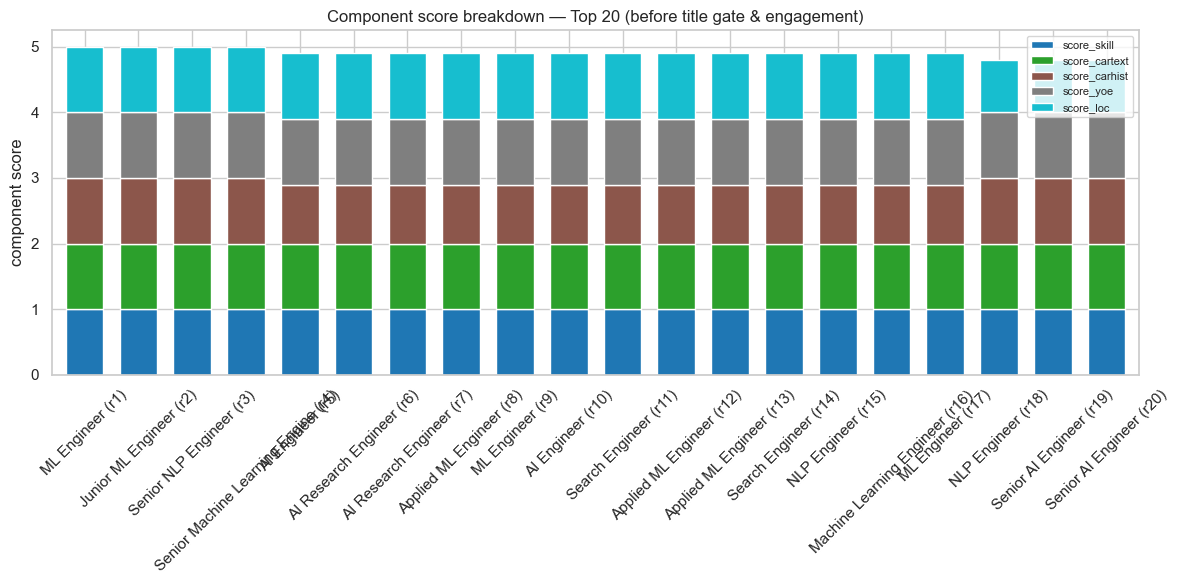

In [14]:
# ── Score breakdown: what's driving the top 20? ───────────────────────────────
breakdown_cols = ['score_title','score_skill','score_cartext','score_carhist',
                  'score_yoe','score_loc','score_eng','score_final']

fig, ax = plt.subplots(figsize=(12, 6))
plot_data = df.head(20)[breakdown_cols].copy()
plot_data.index = df.head(20)['title'].str[:30] + ' (r' + df.head(20).index.astype(str) + ')'
plot_data[['score_skill','score_cartext','score_carhist','score_yoe','score_loc']].plot(
    kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.7)
ax.set_title('Component score breakdown — Top 20 (before title gate & engagement)')
ax.set_ylabel('component score')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'v1_component_breakdown.png', dpi=120)
plt.show()

## Section 6 — Save CSV & Validate

Submission format: `candidate_id` column, rows ranked 1–100.

In [15]:
# Save submission CSV (top 100, candidate_id only)
submission = df.head(100)[['candidate_id']].copy()
submission.to_csv(OUT_CSV, index=False)
print(f'Saved: {OUT_CSV}')
print(f'Rows: {len(submission)}')
print('\nFirst 5 rows:')
print(submission.head())

Saved: ..\outputs\submission_v1_rulebased.csv
Rows: 100

First 5 rows:
   candidate_id
1  CAND_0040178
2  CAND_0053527
3  CAND_0092278
4  CAND_0018499
5  CAND_0087630


In [16]:
# ── Inline validation ─────────────────────────────────────────────────────────
submission_check = pd.read_csv(OUT_CSV)

assert 'candidate_id' in submission_check.columns, 'FAIL: missing candidate_id column'
assert len(submission_check) == 100, f'FAIL: expected 100 rows, got {len(submission_check)}'
assert submission_check['candidate_id'].nunique() == 100, 'FAIL: duplicate candidate_ids'

# No honeypots in submission
submitted_ids = set(submission_check['candidate_id'].tolist())
hp_ids = set(df[df['is_honeypot']]['candidate_id'].tolist())
hp_in_submission = submitted_ids & hp_ids
print(f'Honeypots in submission: {len(hp_in_submission)}  ← 0 required')

# No stuffers in submission
stuffer_ids = set(df[df['is_stuffer']]['candidate_id'].tolist())
stuffers_in_submission = submitted_ids & stuffer_ids
print(f'Keyword stuffers in submission: {len(stuffers_in_submission)}  ← 0 required')

# All validation passed
print('\n✓ candidate_id column present')
print('✓ exactly 100 rows')
print('✓ no duplicate IDs')
print(f'\nSubmission ready: {OUT_CSV}')

Honeypots in submission: 0  ← 0 required
Keyword stuffers in submission: 0  ← 0 required

✓ candidate_id column present
✓ exactly 100 rows
✓ no duplicate IDs

Submission ready: ..\outputs\submission_v1_rulebased.csv


In [17]:
# ── Save full scored DataFrame for next notebook ─────────────────────────────
# The BM25 notebook will load this to compare rankings.
full_out = OUT_DIR / 'scored_v1_full.parquet'
df.reset_index(names='rank').to_parquet(full_out, index=False)
print(f'Full scored dataset saved: {full_out}')
print(f'Shape: {df.shape}')

Full scored dataset saved: ..\outputs\scored_v1_full.parquet
Shape: (100000, 48)


In [18]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('RULE-BASED V1 — SUMMARY')
print('=' * 60)
print(f"Total candidates:       {len(df):,}")
print(f"Honeypots excluded:     {df['is_honeypot'].sum():,}")
print(f"Keyword stuffers found: {df['is_stuffer'].sum():,}")
print(f"Non-zero scores:        {(df['score_final'] > 0).sum():,}")
print()
print(f"Score at rank 1:        {df['score_final'].iloc[0]:.4f}")
print(f"Score at rank 10:       {df['score_final'].iloc[9]:.4f}")
print(f"Score at rank 100:      {df['score_final'].iloc[99]:.4f}")
print(f"Score at rank 101:      {df['score_final'].iloc[100]:.4f}")
print()
print('Top 5 titles in top 100:')
for title, cnt in df.head(100)['title'].value_counts().head(5).items():
    print(f'  {cnt:3d}  {title}')
print()
print('Countries in top 100:')
for country, cnt in df.head(100)['country'].value_counts().items():
    print(f'  {cnt:3d}  {country}')
print()
print('What breaks this V1 ranker → reason to move to BM25/TF-IDF:')
print('  - Career text score is bag-of-words exact-match only')
print('  - "dense retrieval" ≠ "dense" OR "retrieval" separately')
print('  - Skill duration data can be fabricated (honeypot variant)')
print('  - Title tier list is finite — new job titles get score=0.15')

RULE-BASED V1 — SUMMARY
Total candidates:       100,000
Honeypots excluded:     53
Keyword stuffers found: 8,101
Non-zero scores:        99,947

Score at rank 1:        0.7000
Score at rank 10:       0.6895
Score at rank 100:      0.6661
Score at rank 101:      0.6658

Top 5 titles in top 100:
   15  AI Research Engineer
   11  Applied ML Engineer
   11  ML Engineer
    8  AI Specialist
    7  Junior ML Engineer

Countries in top 100:
   95  India
    3  USA
    1  Singapore
    1  Australia

What breaks this V1 ranker → reason to move to BM25/TF-IDF:
  - Career text score is bag-of-words exact-match only
  - "dense retrieval" ≠ "dense" OR "retrieval" separately
  - Skill duration data can be fabricated (honeypot variant)
  - Title tier list is finite — new job titles get score=0.15
